# Doubly Positive but not Totally Positive Kernel

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:sinkhorn-doubly-positive-counterexample`. It illustrates the gap between a kernel that is positive semidefinite and pointwise positive, and a kernel that admits positive features on every finite restriction. The example is the periodic kernel
$$
    k_\lambda(x,y)=\lambda+\cos^2\!\left(\frac{x-y}{2}\right),
$$
sampled on five equally spaced points of the circle. For a small positive $\lambda$, the Gram matrix is entrywise positive and positive semidefinite, but a Horn copositive certificate proves that it is not completely positive.


## Numerical Certificate

The matrix $H$ used below is the classical Horn copositive matrix. Every completely positive matrix $B$ satisfies $\langle H,B\rangle\geq 0$. A negative value for $\langle H,K\rangle$ therefore certifies that the positive semidefinite nonnegative Gram matrix $K$ cannot be written as $BB^\top$ with $B\geq0$.


In [ ]:
# --- OT4ML_COLAB_BOOTSTRAP: make this figure notebook runnable standalone in Colab.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys


def _ot4ml_find_repo_root():
    """Locate the OT4ML repository root used by this notebook.
    
    Returns:
        Located path or object requested by the routine.
    """
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install a package when the corresponding module is missing.
    
    Args:
        module_name: Python module name that should be importable.
        package_name: Package name to install when the module is unavailable.
    
    Returns:
        None. The function is executed for its side effects.
    """
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    ROOT = _OT4ML_Path("/content/ot4ml") if "google.colab" in _OT4ML_sys.modules else _OT4ML_Path.cwd() / "ot4ml"
    if ROOT.exists() and any(ROOT.iterdir()) and not (ROOT / ".git").exists():
        ROOT = ROOT.with_name(ROOT.name + "-repo")
    if not (ROOT / "notebooks-figures" / "figure_style.py").exists():
        _OT4ML_subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/gpeyre/ot4ml.git", str(ROOT)],
            check=True,
        )

_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)

if "google.colab" in _OT4ML_sys.modules:
    pass


In [ ]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec

from figure_style import BLUE, GRAY, RED, VIOLET, ROOT, figure_dir, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "sinkhorn-doubly-positive-counterexample"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails"
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB.mkdir(parents=True, exist_ok=True)
ARXIV_OUT.mkdir(parents=True, exist_ok=True)

lam = 0.05
n = 5
x = 2 * np.pi * np.arange(n) / n
D = x[:, None] - x[None, :]
K = lam + np.cos(0.5 * D) ** 2

def kernel(t):
    """Compute the kernel used by this notebook.
    
    Args:
        t: Interpolation time or evolution time parameter.
    
    Returns:
        kernel for the current computation.
    """
    return lam + np.cos(0.5 * t) ** 2

H = np.array(
    [
        [1, -1, 1, 1, -1],
        [-1, 1, -1, 1, 1],
        [1, -1, 1, -1, 1],
        [1, 1, -1, 1, -1],
        [-1, 1, 1, -1, 1],
    ],
    dtype=float,
)

eigs = np.linalg.eigvalsh(K)
horn_value = float(np.sum(H * K))
psd_min = float(eigs.min())
entry_min = float(K.min())

fig = plt.figure(figsize=(8.2, 2.35))
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.25, 1.0, 1.0], wspace=0.34)

ax0 = fig.add_subplot(gs[0, 0])
t = np.linspace(-np.pi, np.pi, 500)
ax0.plot(t / np.pi, kernel(t), color=VIOLET, lw=1.8)
for d in [0, 2*np.pi/5, 4*np.pi/5, -2*np.pi/5, -4*np.pi/5]:
    ax0.scatter([d / np.pi], [kernel(d)], s=18, color=RED, zorder=4)
ax0.axhline(0, color="#222222", lw=0.55)
ax0.set_xlim(-1, 1)
ax0.set_ylim(0, 1.1 * kernel(0))
ax0.set_xlabel(r"$t/\pi$")
ax0.set_ylabel(r"$k_\lambda(t)$")
ax0.set_title(r"$k_\lambda(t)=\lambda+\cos^2(t/2)$", fontsize=9, pad=4)
ax0.grid(True, lw=0.35, color="#dddddd")

ax1 = fig.add_subplot(gs[0, 1])
im = ax1.imshow(K, cmap="RdPu", vmin=0, vmax=K.max(), interpolation="nearest")
for i in range(n + 1):
    ax1.axhline(i - 0.5, color="white", lw=0.75)
    ax1.axvline(i - 0.5, color="white", lw=0.75)
ax1.set_xticks(range(n), [rf"${j}$" for j in range(1, n + 1)])
ax1.set_yticks(range(n), [rf"${j}$" for j in range(1, n + 1)])
ax1.tick_params(length=0)
ax1.set_title("five-point Gram matrix", fontsize=9, pad=4)
for spine in ax1.spines.values():
    spine.set_visible(False)

ax2 = fig.add_subplot(gs[0, 2])
colors = [BLUE if v > 1e-10 else GRAY for v in eigs]


### Panel generation

The next cell iterates over the selected times, parameters, or panels and writes the PDF files used by the book.  The mathematical solve has already been encoded above; this block mainly controls reproducible rendering.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


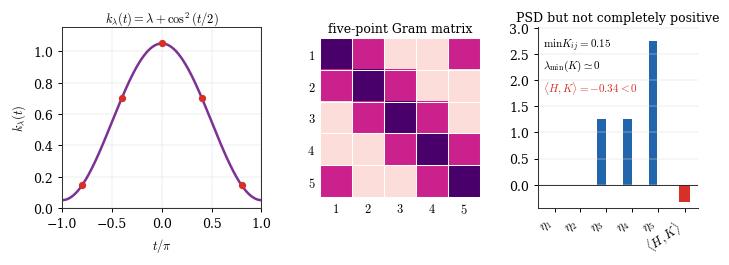

{'lambda': 0.05,
 'min_entry': 0.14549150281252624,
 'min_eigenvalue': -4.570044813919779e-16,
 'horn_inner_product': -0.34016994374947473}

In [1]:
ax2.bar(np.arange(n) - 0.18, eigs, width=0.34, color=colors, edgecolor="none", label="eigenvalues")
ax2.bar([n + 0.05], [horn_value], width=0.45, color=RED, edgecolor="none", label="Horn")
ax2.axhline(0, color="#222222", lw=0.65)
ax2.set_xticks(list(np.arange(n)) + [n + 0.05], [rf"$\eta_{j}$" for j in range(1, n + 1)] + [r"$\langle H,K\rangle$"], rotation=35, ha="right")
ax2.set_ylim(min(-0.45, 1.2 * horn_value), max(2.8, 1.1 * eigs.max()))
ax2.set_title("PSD but not completely positive", fontsize=9, pad=4)
ax2.text(0.03, 0.95, rf"$\min K_{{ij}}={entry_min:.2f}$", transform=ax2.transAxes, ha="left", va="top", fontsize=8)
ax2.text(0.03, 0.83, r"$\lambda_{\min}(K)\simeq 0$", transform=ax2.transAxes, ha="left", va="top", fontsize=8)
ax2.text(0.03, 0.71, rf"$\langle H,K\rangle={horn_value:.2f}<0$", transform=ax2.transAxes, ha="left", va="top", fontsize=8, color=RED)
ax2.grid(axis="y", lw=0.35, color="#dddddd")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

fig.savefig(THUMB / f"{NAME}.png", dpi=220, bbox_inches="tight", pad_inches=0.04)
save_pdf(fig, OUT / "counterexample.pdf", pad_inches=0.035)
fig.savefig(ARXIV_OUT / f"{NAME}--counterexample.pdf", bbox_inches="tight", pad_inches=0.035)
plt.show()

{
    "lambda": lam,
    "min_entry": entry_min,
    "min_eigenvalue": psd_min,
    "horn_inner_product": horn_value,
}
